# Kayson's script, heavily adapted. 

Goal: Figure out hparams, that allow a good separation between different weight matrices. 

In [78]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
# import generative as gen
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
# import utils as ut
import seaborn as sns
import h5py
from vizman import viz
import networkx as nx
from netneurotools.networks import threshold_network
import pandas as pd

In [80]:
viz.set_visual_style()
viz_sizes = viz.load_data_from_json("sizes.json")
viz_colors = viz.load_data_from_json("colors.json")
viz_cmaps = viz.give_colormaps()
sns_kwargs = {"cmap": viz_cmaps["bw_lr"],
              "xticklabels":False,
              "yticklabels":False,
              "rasterized":True}

In [81]:
colors = [viz_colors["colds"]["LAKE_BLUE"], # routing
          viz_colors["neutrals"]["OLIVE_GRAY"], # diffusion
          viz_colors["purples"]["PURPLER"], # propagation
          viz_colors["warms"]["LECKER_RED"], # empirical
          "#a2313a", # long-range rewired
          "#C6C7C4", # randomized
          "#A2999E", # latticized
          "#353B3C"] # erdos-renyi

In [82]:
N_regions = 100
N_subjects = 1
measure = "memory capacity"

In [83]:
from functools import partial
from sklearn.model_selection import train_test_split
from echoes import ESNRegressor

from src.analysis.utils_kayson_damicelli import forgetting, make_X_y
import src.analysis.utils_kayson_damicelli as ut

from pathlib import Path

In [84]:
output_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/05_tuning_ESNs") 

In [85]:
lags=np.arange(1, 41)
X, y = ut.make_X_y(
    make_X=partial(np.random.uniform, low=0, high=1, size=3000),
    lags=lags,
    # cut=0
    cut=max(lags) # !!!!!
)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2368, 1), (592, 1), (2368, 40), (592, 40))

In [86]:
# Alleine das ändern der input_scaling auf 10e-3 hat die MC stark verbessert... Das als neue property, die dann weniger noisy ist? 

In [87]:

# # Assume propagation_matrices and thresholded_connectivities are available, shape: (N_regions, N_regions, N_subjects)
# N_regions, _, _ = diffusion_matrices.shape # propagation_matrices.shape
# N_tops = [1, 5, 10, 15, 20]
# N_trials = 100

# propagation_performances = np.zeros((N_trials, N_subjects, len(N_tops)))
# empirical_performances = np.zeros((N_trials, N_subjects, len(N_tops)))

# for idx, N_top in enumerate(N_tops):
#     propagation_mask = np.ones((N_subjects, N_regions))
#     # empirical_mask = np.ones((N_subjects, N_regions))

#     for subject in range(N_subjects):
#         # Propagation: zero out top N_top highest-degree regions
#         A_prop = diffusion_matrices[..., subject]
#         degree_prop = A_prop.sum(axis=0)
#         top_idx_prop = np.argsort(degree_prop)[::-1][:max(0, min(N_top, N_regions))]
#         mask_prop = np.ones_like(degree_prop)
#         if top_idx_prop.size > 0:
#             mask_prop[top_idx_prop] = 0
#         propagation_mask[subject] = mask_prop
        
#     for subject in tqdm(range(N_subjects),total=N_subjects):
#         for trial in range(N_trials):          
#             # Propagation
#             esn = ESNRegressor(W=np.array(diffusion_matrices[...,subject]), # , dtype=np.float32),
#                                 input_scaling=0.1, # 1, # 1e-3, # 0.5,
#                                 leak_rate=0.3, 
#                                 bias=0, 
#                                 n_transient=100,
#                                 random_state=subject+trial
#                                 )
#             y_pred = esn.fit(X_train, y_train).predict(X_test)

#             propagation_performances[trial,subject,idx]=ut.forgetting(y_test[100:], y_pred[100:])[1]


# plt.plot(ut.forgetting(y_test[100:], y_pred[100:])[0])
# print("MC:", ut.forgetting(y_test[100:], y_pred[100:])[1])

In [88]:
from scipy.stats import pearsonr

In [89]:
# y_pred, y_test

# r2_lags = []
# for i in range(40):
#     corr, _ = pearsonr(y_test[100:, i], y_pred[100:, i]) # Discard initial transient. (statistic, p_value)
#     r2_lags.append(corr**2) 
#     # print(f"Lag {i+1}: R^2 = {corr**2:.4f}")

In [90]:
# # 3. Calculate the MC score
# mc_score = 0
# r2_scores = []
# for i in range(40):
#     # Discard initial transient phase from test data for stable correlation
#     corr, _ = pearsonr(y_test[h_params["n_transient"]:, i], y_pred[h_params["n_transient"]:, i]) # Discard initial transient. (statistic, p_value)
#     r2_scores.append(corr**2)
#     mc_score += corr**2


In [91]:
diffusion_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion_10_percent.npy")
diffusion_matrices_10 = diffusion_matrices_10.T

propagation_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_10_percent.npy")
propagation_matrices_10 = propagation_matrices_10.T

routing_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/routing_10_percent.npy") 
routing_matrices_10 = routing_matrices_10.T

topology_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_topology/01_connectomes/topology_10_percent.npy") 
topology_matrices_10 = topology_matrices_10.T

diffusion_matrices_20 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_20_percent_gen_by_kayson.npy")
diffusion_matrices_20 = diffusion_matrices_20[:,:,:1]

developing_matrices = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_individual_connectomes_bin.npy")
developing_matrices = developing_matrices.T[:,:,:1]

A_arr = [diffusion_matrices_10,
         propagation_matrices_10,
         routing_matrices_10,
         topology_matrices_10,
         developing_matrices]

labels = ["Diffusion-10", "Propagation-10", "Routing-10", "Topology-10", "Developing"]

diffusion_matrices_10.shape, diffusion_matrices_20.shape, developing_matrices.shape

((100, 100, 1), (100, 100, 1), (100, 100, 1))

In [92]:
# plt.imshow(diffusion_matrices_10[...,0])   
# plt.imshow(diffusion_matrices_20[...,0])   
# plt.imshow(developing_matrices[...,0])    

100%|██████████| 1/1 [00:04<00:00,  4.35s/it]

Lin MC: 23.902946311806318
Non-Lin MC: 22.265604503281125


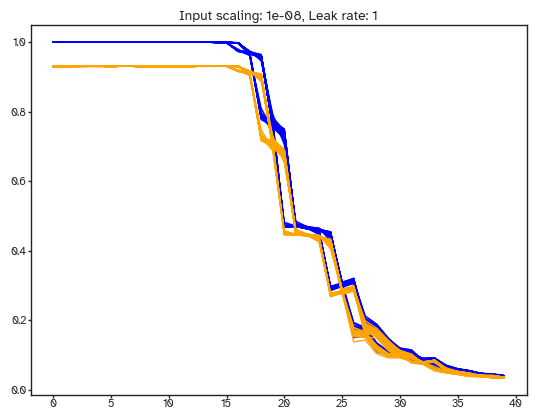

100%|██████████| 1/1 [00:04<00:00,  4.12s/it]

Lin MC: 19.148300869017305
Non-Lin MC: 17.81428080525412


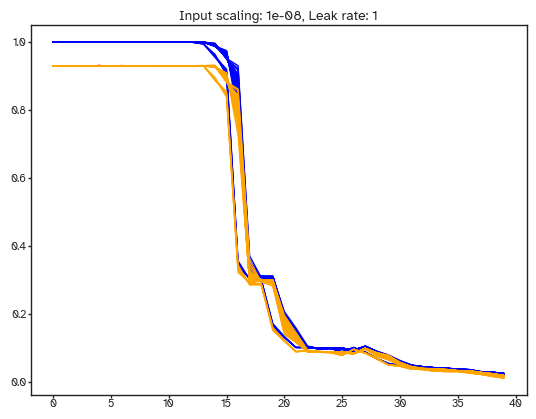

100%|██████████| 1/1 [00:04<00:00,  4.29s/it]

Lin MC: 11.964462353782078
Non-Lin MC: 11.600547506163748


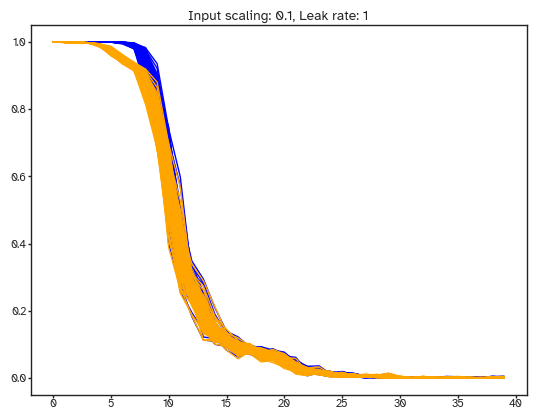

100%|██████████| 1/1 [00:04<00:00,  4.18s/it]

Lin MC: 10.633761054828872
Non-Lin MC: 10.326385603094819


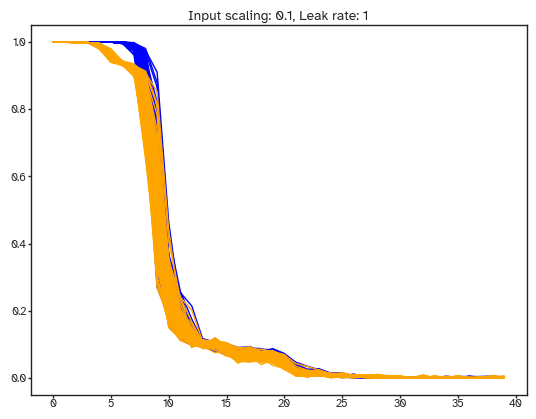

100%|██████████| 1/1 [00:04<00:00,  4.26s/it]

Lin MC: 8.611067865464895
Non-Lin MC: 8.545974092617934


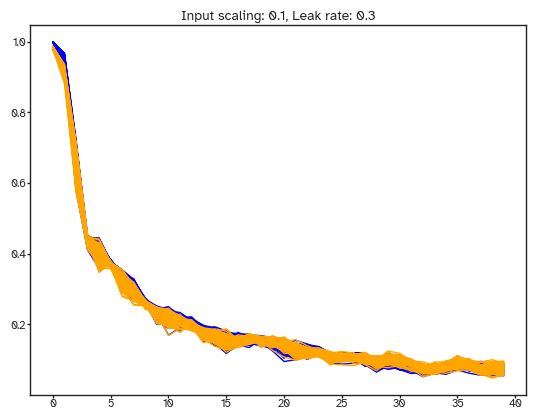

100%|██████████| 1/1 [00:04<00:00,  4.40s/it]

Lin MC: 7.988657854883428
Non-Lin MC: 7.921732136193895


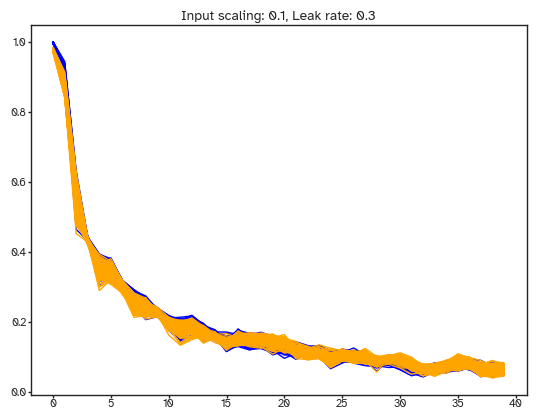

100%|██████████| 1/1 [00:04<00:00,  4.22s/it]

Lin MC: 22.98198439931829
Non-Lin MC: 21.816935240931038


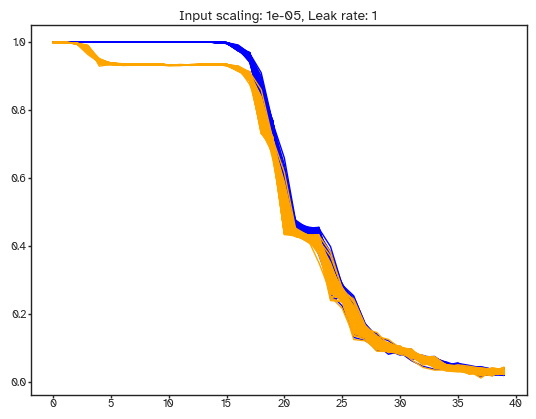

100%|██████████| 1/1 [00:04<00:00,  4.51s/it]

Lin MC: 18.381025682723923
Non-Lin MC: 17.43823184911604


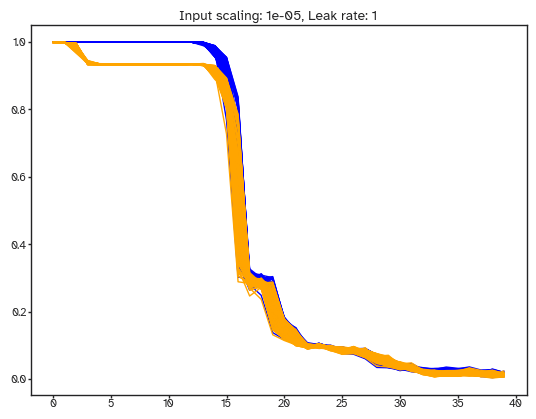

  0%|          | 0/1 [00:00<?, ?it/s]/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:

Lin MC: nan
Non-Lin MC: nan


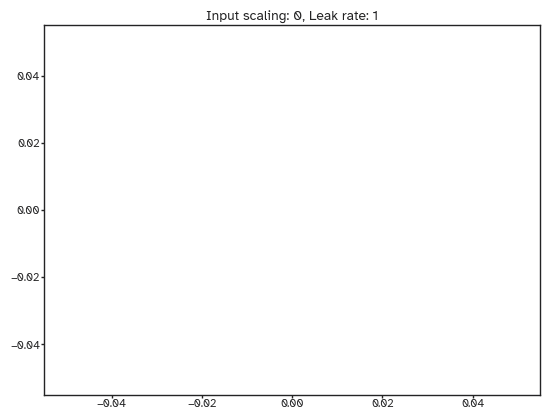

  0%|          | 0/1 [00:00<?, ?it/s]/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:

Lin MC: nan
Non-Lin MC: nan


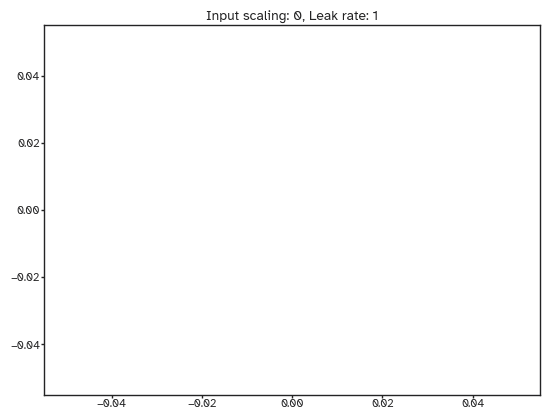

In [97]:
def plot_forgetting_curve(A, input_scaling, leak_rate):  # , y_test, y_pred):

    N_regions, _, _ = A.shape
    N_trials = 100
    results_lin = []
    results_nonlin = []
    mc_avg_lin = []
    mc_avg_nonlin = []

    for subject in tqdm(range(N_subjects),total=N_subjects):
        for trial in range(N_trials):          
            # Propagation
            esn = ESNRegressor(W=np.array(A[...,subject]), # , dtype=np.float32),
                               spectral_radius=0.9,
                                input_scaling=input_scaling,
                                leak_rate=leak_rate,
                                bias=0, 
                                # bias=0.5,
                                n_transient=100,
                                # W_in=np.array(propagation_mask[subject][:,np.newaxis], dtype=np.float32),
                                random_state=subject+trial
                                )
            y_pred = esn.fit(X_train, y_train).predict(X_test)
            result = ut.forgetting(y_test[100:], y_pred[100:])
            results_lin.append(result[0])
            mc_avg_lin.append(result[1])
            
            y_pred_nonlin = esn.fit(X_train, y_train**2).predict(X_test)
            result_nonlin = ut.forgetting(y_test[100:]**2, y_pred_nonlin[100:])
            results_nonlin.append(result_nonlin[0])
            mc_avg_nonlin.append(result_nonlin[1])

        plt.plot(np.array(results_lin).T, color="blue", label="Linear")
        plt.plot(np.array(results_nonlin).T, color="orange", label="Non-Linear")
        print("Lin MC:", np.array(mc_avg_lin).mean())
        print("Non-Lin MC:", np.array(mc_avg_nonlin).mean())

    # plt.legend()
    plt.title(f"Input scaling: {input_scaling}, Leak rate: {leak_rate}")    
    plt.show()
    
plot_forgetting_curve(diffusion_matrices_10, input_scaling=1e-8, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=1e-8, leak_rate=1)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=0.1, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0.1, leak_rate=1)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=0.1, leak_rate=0.3)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0.1, leak_rate=0.3)

plot_forgetting_curve(diffusion_matrices_10, input_scaling=1e-5, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=1e-5, leak_rate=1)


plot_forgetting_curve(diffusion_matrices_10, input_scaling=0, leak_rate=1)
plot_forgetting_curve(diffusion_matrices_20, input_scaling=0, leak_rate=1)


In [100]:
def plot_forgetting_curve(A, ax, label="", spectral_radius=0.9, input_scaling=0.1, leak_rate=0.3):
    """
    Plots mean ± std forgetting curve across subjects and trials into a given axis.
    Returns (mean_lin_MC, mean_nonlin_MC) for comparison.
    """
    _, _, N_subjects = A.shape
    N_trials = 100

    # Shape: (N_subjects * N_trials, n_lags)
    results_lin    = []
    results_nonlin = []
    mc_lin         = []
    mc_nonlin      = []

    for subject in range(N_subjects):
        for trial in range(N_trials):
            esn = ESNRegressor(
                W=np.array(A[..., subject], dtype=np.float64),
                spectral_radius=spectral_radius,
                input_scaling=input_scaling,
                leak_rate=leak_rate,
                bias=0,
                n_transient=100,
                random_state=subject + trial,
            )

            # Linear MC
            y_pred = esn.fit(X_train, y_train).predict(X_test)
            r_lin  = ut.forgetting(y_test[100:], y_pred[100:])
            results_lin.append(r_lin[0])
            mc_lin.append(r_lin[1])

            # Nonlinear MC
            y_pred_nl = esn.fit(X_train, y_train**2).predict(X_test)
            r_nonlin  = ut.forgetting(y_test[100:]**2, y_pred_nl[100:])
            results_nonlin.append(r_nonlin[0])
            mc_nonlin.append(r_nonlin[1])

    results_lin    = np.array(results_lin)    # (N_subjects*N_trials, n_lags)
    results_nonlin = np.array(results_nonlin)

    lags = np.arange(results_lin.shape[1])

    # Plot mean ± std
    for arr, color, name in [
        (results_lin,    "steelblue", "Linear"),
        (results_nonlin, "darkorange", "Nonlinear"),
    ]:
        mean = arr.mean(axis=0)
        std  = arr.std(axis=0)
        ax.plot(lags, mean, color=color, label=name)
        ax.fill_between(lags, mean - std, mean + std, alpha=0.2, color=color)

    mean_mc_lin    = np.mean(mc_lin)
    mean_mc_nonlin = np.mean(mc_nonlin)

    ax.set_title(f"{label}\nMC lin={mean_mc_lin:.2f}, MC nl={mean_mc_nonlin:.2f}", fontsize=8)
    ax.set_xlabel("Lag k")
    ax.set_ylabel("R²")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

    return mean_mc_lin, mean_mc_nonlin

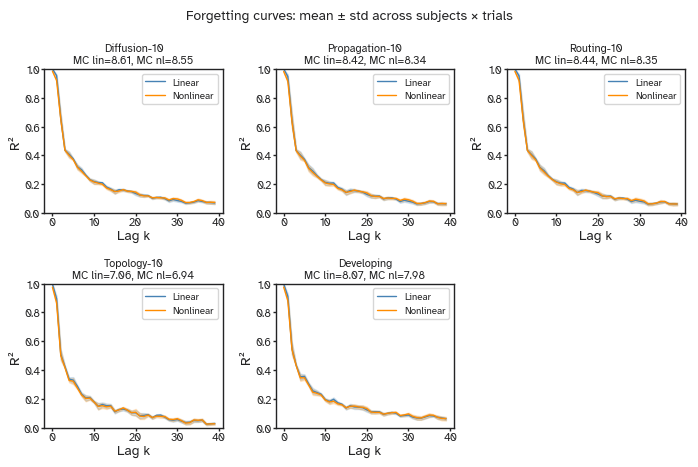

                  lin  nonlin
Diffusion-10    8.611   8.546
Propagation-10  8.418   8.342
Routing-10      8.437   8.354
Topology-10     7.064   6.941
Developing      8.070   7.982


In [95]:
fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , sharex=True, sharey=True)

mc_results = {}
for A, label, ax in zip(A_arr, labels, axs.flatten()):
    mc_lin, mc_nonlin = plot_forgetting_curve(
        A, ax=ax, label=label,
        input_scaling=0.1,   # literature-justified: meaningful input drive
        leak_rate=0.3,        # slower timescale; better for delayed memory tasks
    )
    mc_results[label] = {"lin": mc_lin, "nonlin": mc_nonlin}

# Hide unused subplots if len(A_arr) < 6
for ax in axs.flatten()[len(A_arr):]: 
    ax.set_visible(False)

fig.suptitle("Forgetting curves: mean ± std across subjects × trials", fontsize=10)
fig.tight_layout()
plt.savefig(output_path / "forgetting_curves.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(pd.DataFrame(mc_results).T.round(3))

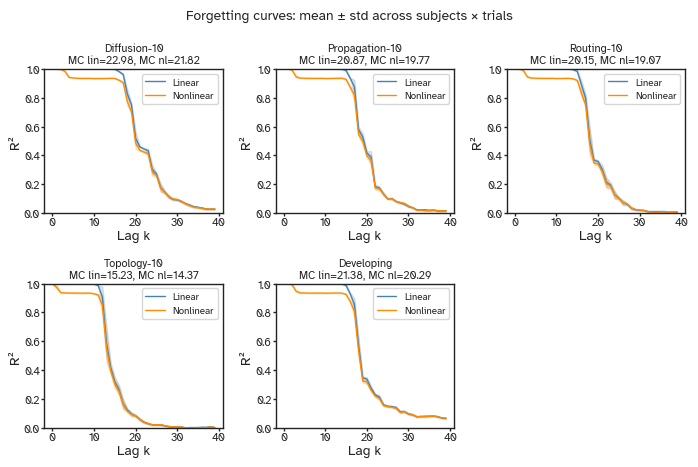

                   lin  nonlin
Diffusion-10    22.982  21.817
Propagation-10  20.870  19.771
Routing-10      20.154  19.072
Topology-10     15.226  14.370
Developing      21.380  20.293


In [96]:
fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , sharex=True, sharey=True)

mc_results = {}
for A, label, ax in zip(A_arr, labels, axs.flatten()):
    mc_lin, mc_nonlin = plot_forgetting_curve(
        A, ax=ax, label=label,
        input_scaling=1e-5,  # literature-justified: meaningful input drive
        leak_rate=1, # .3,        # slower timescale; better for delayed memory tasks
    )
    mc_results[label] = {"lin": mc_lin, "nonlin": mc_nonlin}

# Hide unused subplots if len(A_arr) < 6
for ax in axs.flatten()[len(A_arr):]:
    ax.set_visible(False)

fig.suptitle("Forgetting curves: mean ± std across subjects × trials", fontsize=10)
fig.tight_layout()
plt.savefig(output_path / "forgetting_curves.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(pd.DataFrame(mc_results).T.round(3))

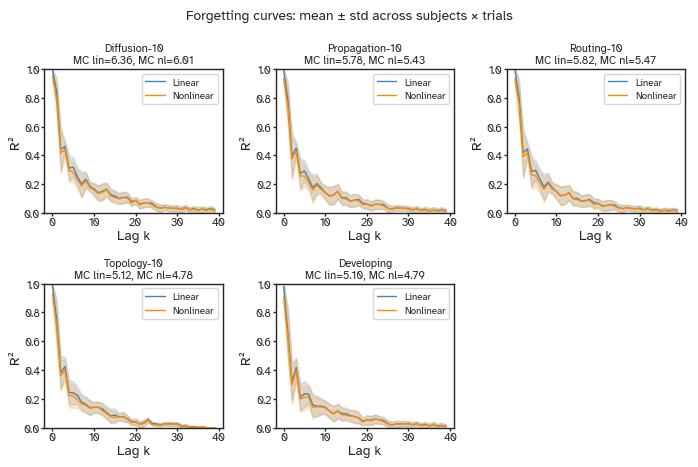

                  lin  nonlin
Diffusion-10    6.359   6.007
Propagation-10  5.777   5.429
Routing-10      5.816   5.468
Topology-10     5.121   4.782
Developing      5.100   4.792


In [ ]:
fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , sharex=True, sharey=True)

mc_results = {}
for A, label, ax in zip(A_arr, labels, axs.flatten()):
    mc_lin, mc_nonlin = plot_forgetting_curve(
        A, ax=ax, label=label,
        spectral_radius=0.99,
        input_scaling=0.1,   # literature-justified: meaningful input drive
        leak_rate=0.3,        # slower timescale; better for delayed memory tasks
    )
    mc_results[label] = {"lin": mc_lin, "nonlin": mc_nonlin}

# Hide unused subplots if len(A_arr) < 6
for ax in axs.flatten()[len(A_arr):]:
    ax.set_visible(False)

fig.suptitle("Forgetting curves: mean ± std across subjects × trials", fontsize=10)
fig.tight_layout()
plt.savefig(output_path / "forgetting_curves.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(pd.DataFrame(mc_results).T.round(3))

In [ ]:
mc_results

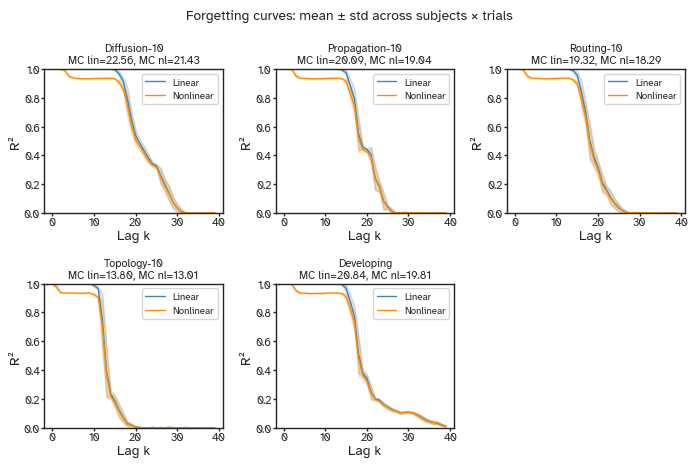

                   lin  nonlin
Diffusion-10    22.555  21.432
Propagation-10  20.091  19.042
Routing-10      19.320  18.290
Topology-10     13.796  13.006
Developing      20.839  19.805


In [ ]:
fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , sharex=True, sharey=True)

mc_results = {}
for A, label, ax in zip(A_arr, labels, axs.flatten()):
    mc_lin, mc_nonlin = plot_forgetting_curve(
        A, ax=ax, 
        label=label,
        spectral_radius=0.99,
        input_scaling=1e-5,  # damicelli 
        leak_rate=1, # .3,        
    )
    mc_results[label] = {"lin": mc_lin, "nonlin": mc_nonlin}

# Hide unused subplots if len(A_arr) < 6
for ax in axs.flatten()[len(A_arr):]:
    ax.set_visible(False)

fig.suptitle("Forgetting curves: mean ± std across subjects × trials", fontsize=10)
fig.tight_layout()
plt.savefig(output_path / "forgetting_curves.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(pd.DataFrame(mc_results).T.round(3))

In [66]:
# ── 1. Lightweight MC scorer (no plotting) ───────────────────────────────────

def compute_mc(A, spectral_radius, input_scaling, leak_rate, N_trials=20):
    """
    Returns mean linear and nonlinear MC across subjects and trials.
    N_trials kept low (20) for grid search speed; increase for final eval.
    """
    _, _, N_subjects = A.shape
    mc_lin, mc_nonlin = [], []

    for subject in range(N_subjects):
        for trial in range(N_trials):
            esn = ESNRegressor(
                W=np.array(A[..., subject], dtype=np.float64),
                spectral_radius=spectral_radius,
                input_scaling=input_scaling,
                leak_rate=leak_rate,
                bias=0,
                n_transient=100,
                random_state=subject + trial,
            )
            y_pred    = esn.fit(X_train, y_train).predict(X_test)
            mc_lin.append(ut.forgetting(y_test[100:], y_pred[100:])[1])

            y_pred_nl = esn.fit(X_train, y_train**2).predict(X_test)
            mc_nonlin.append(ut.forgetting(y_test[100:]**2, y_pred_nl[100:])[1])

    return np.mean(mc_lin), np.mean(mc_nonlin)


# ── 2. Grid search ────────────────────────────────────────────────────────────

spectral_radii  = [0.5, 0.9, 0.95, 0.99, 1.0, 1.2]
input_scalings  = [1e-8, 1e-5, 1e-3, 0.01, 0.1, 1.0]
leak_rates      = [0.1, 0.3, 0.5, 1.0]

rows = []
for label, A in tqdm(zip(labels, A_arr), total=len(A_arr), desc="Matrices"):
    for sr in spectral_radii:
        for isc in input_scalings:
            for lr in leak_rates:
                mc_l, mc_nl = compute_mc(np.array(A, dtype=np.float64), 
                                         sr, isc, lr)
                rows.append({
                    "matrix":          label,
                    "spectral_radius": sr,
                    "input_scaling":   isc,
                    "leak_rate":       lr,
                    "mc_lin":          mc_l,
                    "mc_nonlin":       mc_nl,
                })

df = pd.DataFrame(rows)
df.to_csv(output_path / "gridsearch_mc.csv", index=False)   # save so you don't have to rerun
print(df.sort_values("mc_lin", ascending=False).head(10))
print(output_path / "gridsearch_mc.csv")



Matrices: 100%|██████████| 5/5 [10:47<00:00, 129.40s/it]

             matrix  spectral_radius  input_scaling  leak_rate     mc_lin  \
51     Diffusion-10             0.95   1.000000e-08        1.0  23.842660   
27     Diffusion-10             0.90   1.000000e-08        1.0  23.695846   
75     Diffusion-10             0.99   1.000000e-08        1.0  23.321548   
55     Diffusion-10             0.95   1.000000e-05        1.0  23.235253   
31     Diffusion-10             0.90   1.000000e-05        1.0  22.863380   
79     Diffusion-10             0.99   1.000000e-05        1.0  22.441786   
627      Developing             0.95   1.000000e-08        1.0  22.420536   
603      Developing             0.90   1.000000e-08        1.0  22.067446   
651      Developing             0.99   1.000000e-08        1.0  21.962401   
195  Propagation-10             0.95   1.000000e-08        1.0  21.690086   

     mc_nonlin  
51   22.149977  
27   22.003794  
75   21.680758  
55   21.905326  
31   21.537664  
79   21.145175  
627  20.845433  
603  20.478421  

In [70]:
# ── 1. Lightweight MC scorer (no plotting) ───────────────────────────────────

def compute_mc(A, spectral_radius, input_scaling, leak_rate, N_trials=20):
    """
    Returns mean linear and nonlinear MC across subjects and trials.
    N_trials kept low (20) for grid search speed; increase for final eval.
    """
    _, _, N_subjects = A.shape
    mc_lin, mc_nonlin = [], []

    for subject in range(N_subjects):
        for trial in range(N_trials):
            esn = ESNRegressor(
                W=np.array(A[..., subject], dtype=np.float64),
                spectral_radius=spectral_radius,
                input_scaling=input_scaling,
                leak_rate=leak_rate,
                bias=1,
                n_transient=100,
                random_state=subject + trial,
            )
            y_pred    = esn.fit(X_train, y_train).predict(X_test)
            mc_lin.append(ut.forgetting(y_test[100:], y_pred[100:])[1])

            y_pred_nl = esn.fit(X_train, y_train**2).predict(X_test)
            mc_nonlin.append(ut.forgetting(y_test[100:]**2, y_pred_nl[100:])[1])

    return np.mean(mc_lin), np.mean(mc_nonlin)


# ── 2. Grid search ────────────────────────────────────────────────────────────

spectral_radii  = [0.5, 0.9, 0.95, 0.99, 1.0, 1.2]
input_scalings  = [1e-8, 1e-5, 1e-3, 0.01, 0.1, 1.0]
leak_rates      = [0.1, 0.3, 0.5, 1.0]

rows = []
for label, A in tqdm(zip(labels, A_arr), total=len(A_arr), desc="Matrices"):
    for sr in spectral_radii:
        for isc in input_scalings:
            for lr in leak_rates:
                mc_l, mc_nl = compute_mc(np.array(A, dtype=np.float64), 
                                         sr, isc, lr)
                rows.append({
                    "matrix":          label,
                    "spectral_radius": sr,
                    "input_scaling":   isc,
                    "leak_rate":       lr,
                    "mc_lin":          mc_l,
                    "mc_nonlin":       mc_nl,
                })

df_bias_1 = pd.DataFrame(rows)
df_bias_1.to_csv(output_path / "gridsearch_mc_bias1.csv", index=False)   # save so you don't have to rerun
print(df_bias_1.sort_values("mc_lin", ascending=False).head(10))
print(output_path / "gridsearch_mc_bias1.csv")



Matrices: 100%|██████████| 5/5 [10:34<00:00, 126.95s/it]

             matrix  spectral_radius  input_scaling  leak_rate    mc_lin  \
14     Diffusion-10             0.50           0.01        0.5  7.207787   
590      Developing             0.50           0.01        0.5  7.204987   
614      Developing             0.90           0.01        0.5  7.185307   
638      Developing             0.95           0.01        0.5  7.177972   
662      Developing             0.99           0.01        0.5  7.134228   
686      Developing             1.00           0.01        0.5  7.126412   
182  Propagation-10             0.90           0.01        0.5  7.111452   
206  Propagation-10             0.95           0.01        0.5  7.053874   
230  Propagation-10             0.99           0.01        0.5  7.050270   
158  Propagation-10             0.50           0.01        0.5  7.032006   

     mc_nonlin  
14    6.976532  
590   6.979827  
614   6.948068  
638   6.938833  
662   6.896591  
686   6.890210  
182   6.877366  
206   6.823576  
230   6.82

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/05_tuning_ESNs/gridsearch_mc_lin_bias1.pdf


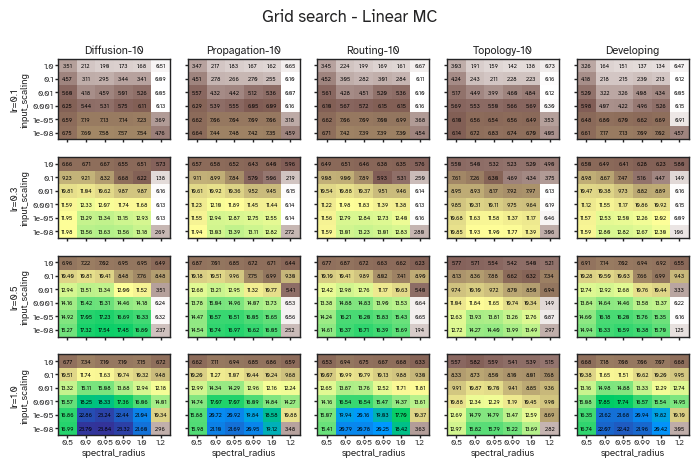

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/05_tuning_ESNs/gridsearch_mc_nonlin_bias1.pdf


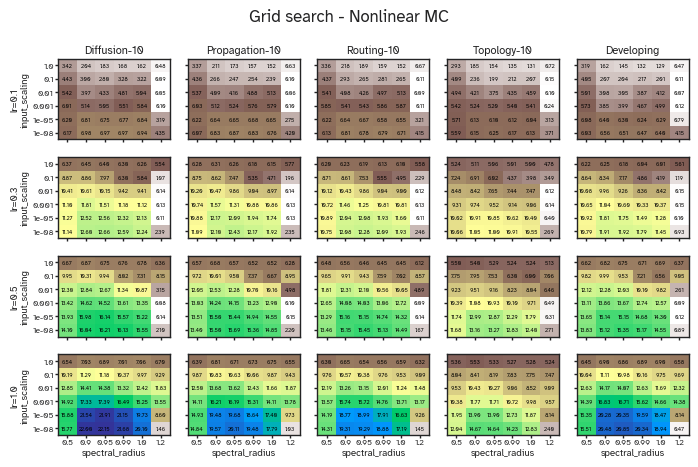

In [71]:

# ── 3. Visualise: heatmaps (sr × input_scaling), one row per leak_rate ───────
#    Columns: one per matrix. Rows: one per leak_rate.
#    Color: linear MC.  Repeat with mc_nonlin for the second figure.

for mc_col, mc_label in [("mc_lin", "Linear MC"), ("mc_nonlin", "Nonlinear MC")]:

    fig, axs = plt.subplots(
        len(leak_rates), len(labels),
        figsize=viz.cm_to_inch((18, 12)), # 6 * len(labels), 4 * len(leak_rates))),
        sharex=True, sharey=True,
    )

    vmin = df[mc_col].min()
    vmax = df[mc_col].max()

    for row_i, lr in enumerate(leak_rates):
        for col_j, label in enumerate(labels):
            ax = axs[row_i, col_j]

            subset = df[(df["matrix"] == label) & (df["leak_rate"] == lr)]
            pivot  = subset.pivot(
                index="input_scaling",
                columns="spectral_radius",
                values=mc_col,
            )

            im = ax.imshow(
                pivot.values,
                aspect="auto",
                vmin=vmin, vmax=vmax,
                cmap="terrain_r", # "viridis",
                origin="lower",
            )
            ax.set_xticks(range(len(spectral_radii)))
            ax.set_xticklabels(spectral_radii, fontsize=6) # , rotation=45)
            ax.set_yticks(range(len(input_scalings)))
            ax.set_yticklabels(input_scalings, fontsize=6)

            # Annotate cells with MC value
            for (r, c), val in np.ndenumerate(pivot.values):
                ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                        fontsize=4, # 5.5, 
                        color="black" # "white" if val < (vmin+vmax)/2 else "black"
                        )

            if row_i == 0:
                ax.set_title(label, fontsize=8)
            if col_j == 0:
                ax.set_ylabel(f"lr={lr}\ninput_scaling", fontsize=7)
            if row_i == len(leak_rates) - 1:
                ax.set_xlabel("spectral_radius", fontsize=7)

    # fig.colorbar(im, ax=axs, shrink=0.6, label=mc_label)
    fig.suptitle(f"Grid search - {mc_label}") # , fontsize=10)
    fig.tight_layout()
    plt.savefig(output_path / f"gridsearch_{mc_col}_bias1.pdf", bbox_inches="tight")
    print(output_path / f"gridsearch_{mc_col}_bias1.pdf")
    plt.show()



In [72]:

# ── 4. Best hparam combo per matrix ──────────────────────────────────────────

best = (df_bias_1.sort_values("mc_lin", ascending=False)
          .groupby("matrix")
          .first()
          [["spectral_radius","input_scaling","leak_rate","mc_lin","mc_nonlin"]]
          .round(3))
print("\nBest hparams per matrix (by linear MC):")
print(best)


Best hparams per matrix (by linear MC):
                spectral_radius  input_scaling  leak_rate  mc_lin  mc_nonlin
matrix                                                                      
Developing                  0.5           0.01        0.5   7.205      6.980
Diffusion-10                0.5           0.01        0.5   7.208      6.977
Propagation-10              0.9           0.01        0.5   7.111      6.877
Routing-10                  0.9           0.01        0.5   6.360      6.194
Topology-10                 0.5           0.01        0.5   5.553      5.414


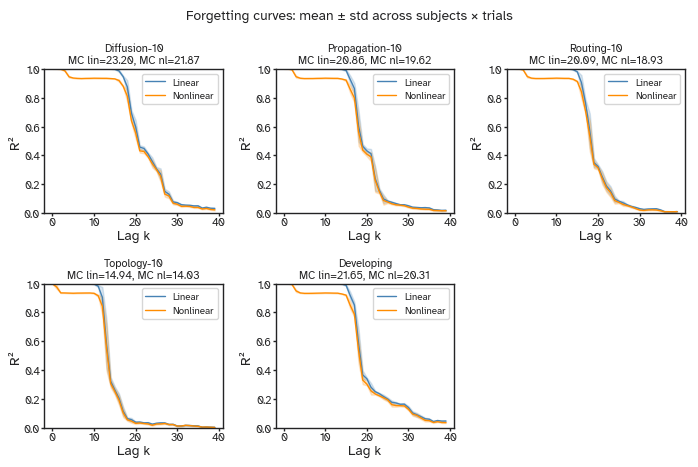

                   lin  nonlin
Diffusion-10    23.195  21.865
Propagation-10  20.860  19.617
Routing-10      20.093  18.927
Topology-10     14.939  14.032
Developing      21.645  20.312


In [73]:
fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , sharex=True, sharey=True)

mc_results = {}
for A, label, ax in zip(A_arr, labels, axs.flatten()):
    mc_lin, mc_nonlin = plot_forgetting_curve(
        A, ax=ax, label=label,
        spectral_radius=0.95,
        input_scaling=1e-5,   # literature-justified: meaningful input drive
        leak_rate=1, # 0.3,        # slower timescale; better for delayed memory tasks
    )
    mc_results[label] = {"lin": mc_lin, "nonlin": mc_nonlin}

# Hide unused subplots if len(A_arr) < 6
for ax in axs.flatten()[len(A_arr):]:
    ax.set_visible(False)

fig.suptitle("Forgetting curves: mean ± std across subjects × trials", fontsize=10)
fig.tight_layout()
plt.savefig(output_path / "forgetting_curves.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(pd.DataFrame(mc_results).T.round(3))

In [ ]:
# from conn2res.tasks import NeuroGymTask

ModuleNotFoundError: No module named 'conn2res'

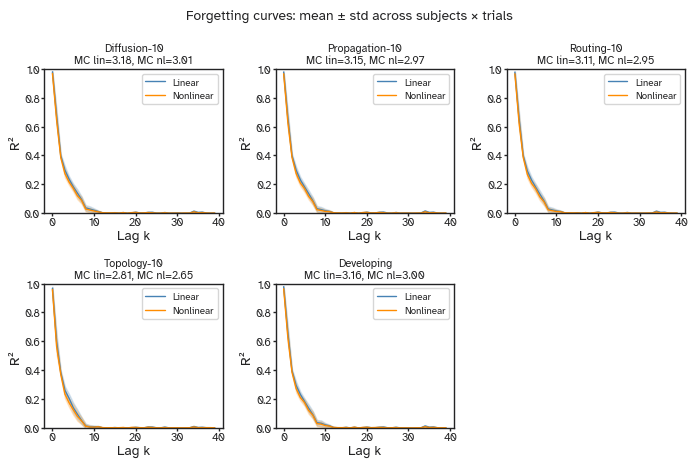

                  lin  nonlin
Diffusion-10    3.184   3.014
Propagation-10  3.146   2.973
Routing-10      3.114   2.945
Topology-10     2.809   2.648
Developing      3.163   2.998


In [76]:
fig, axs = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , sharex=True, sharey=True)

mc_results = {}
for A, label, ax in zip(A_arr, labels, axs.flatten()):
    mc_lin, mc_nonlin = plot_forgetting_curve(
        A, ax=ax, label=label,
        spectral_radius=0.95,
        input_scaling=10,   # literature-justified: meaningful input drive
        leak_rate=0.5, # 0.3,        # slower timescale; better for delayed memory tasks
    )
    mc_results[label] = {"lin": mc_lin, "nonlin": mc_nonlin}

# Hide unused subplots if len(A_arr) < 6
for ax in axs.flatten()[len(A_arr):]:
    ax.set_visible(False)

fig.suptitle("Forgetting curves: mean ± std across subjects × trials", fontsize=10)
fig.tight_layout()
plt.savefig(output_path / "forgetting_curves.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(pd.DataFrame(mc_results).T.round(3))

In [77]:
mnc_results

NameError: name 'mnc_results' is not defined